## Scam Detection using a 1D CNN Model

### Data Loading and Preprocessing

In [2]:
import sys

from data_loader import load_scam_data, load_embeddings

dataset = load_scam_data()
glove = load_embeddings()

glove_weights = glove.vectors

Downloading/Loading SMS Spam dataset...



Sample Data Structure:
{'sms': 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...\n', 'label': 0}

Downloading/Loading GloVe Embeddings...
(Note: This is an ~800MB download the first time you run it. Grab a coffee.)

The shape of the word vector for 'scam' is: torch.Size([100])


In [3]:
## Tokenize and create a vocabulary:

import torch
from collections import Counter

# 1. Flatten all messages to count word frequency
all_text = " ".join(dataset['train']['sms']).lower().split()
word_counts = Counter(all_text)

# 2. Create a vocabulary (only keep words that appear at least twice)
vocab = {"<PAD>": 0, "<UNK>": 1}
for word, count in word_counts.items():
    if count > 1:
        vocab[word] = len(vocab)

print(f"Vocabulary size: {len(vocab)}")

## Create an embedding matrix using GloVe vectors:

embedding_dim = 100
# Initialize matrix with zeros or random numbers
target_vocab_size = len(vocab)
embedding_matrix = torch.zeros((target_vocab_size, embedding_dim))

for word, idx in vocab.items():
    if word in glove.stoi: # Check if word exists in GloVe
        embedding_matrix[idx] = glove.vectors[glove.stoi[word]]
    else:
        # For <UNK> or missing words, use a random normal vector
        embedding_matrix[idx] = torch.randn(embedding_dim)

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Vocabulary size: 5545
Embedding matrix shape: torch.Size([5545, 100])


In [5]:
## Numberize and pad the messages:

def encode_and_pad(text, max_len=50):
    tokens = text.lower().split()
    # Convert words to indices
    indices = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    # Pad or Truncate
    if len(indices) < max_len:
        indices += [vocab["<PAD>"]] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return indices

# Apply to the dataset
train_data = [encode_and_pad(msg) for msg in dataset['train']['sms']]
train_labels = dataset['train']['label'] # 0 for ham, 1 for spam

# Convert to Tensors
X_train = torch.tensor(train_data)
y_train = torch.tensor(train_labels)

In [6]:
from torch.utils.data import TensorDataset, DataLoader

# 1. Split the original Hugging Face dataset (if you haven't already)
# This creates a 80/20 split
split_dataset = dataset['train'].train_test_split(test_size=0.2, seed=42)

# 2. Process Training Data (Re-doing this to ensure consistency)
train_msgs = [encode_and_pad(msg) for msg in split_dataset['train']['sms']]
train_labels = split_dataset['train']['label']
X_train = torch.tensor(train_msgs)
y_train = torch.tensor(train_labels)

# 3. Process Test Data (The missing piece!)
test_msgs = [encode_and_pad(msg) for msg in split_dataset['test']['sms']]
test_labels = split_dataset['test']['label']
X_test = torch.tensor(test_msgs)
y_test = torch.tensor(test_labels)

# 4. Create DataLoaders
batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # No need to shuffle test data

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

Train samples: 4459, Test samples: 1115


In [7]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Test a batch
sample_x, sample_y = next(iter(train_loader))
print(f"Batch X shape: {sample_x.shape}") # Should be [32, 50]

Batch X shape: torch.Size([32, 50])


### Data Visualization

                                                 sms  label
0  Go until jurong point, crazy.. Available only ...      0
1                    Ok lar... Joking wif u oni...\n      0
2  Free entry in 2 a wkly comp to win FA Cup fina...      1
3  U dun say so early hor... U c already then say...      0
4  Nah I don't think he goes to usf, he lives aro...      0
label
0    4827
1     747
Name: count, dtype: int64


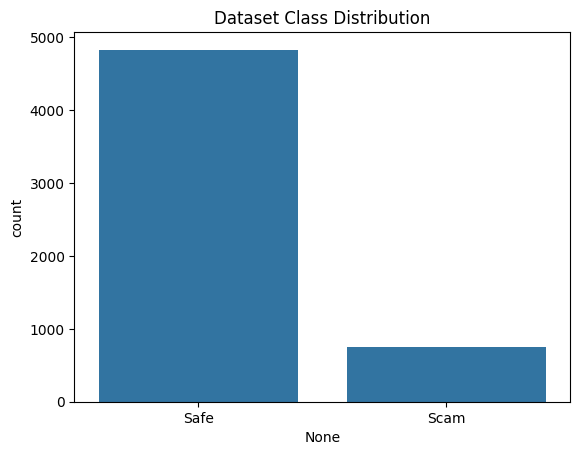

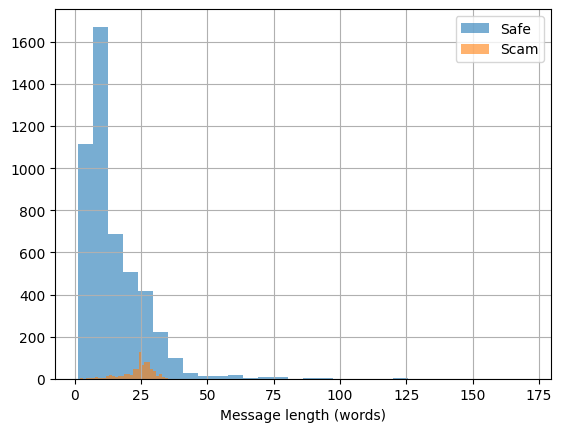

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# basic look
df = pd.DataFrame(dataset['train'])
print(df.head())
print(df['label'].value_counts())  # 0=ham (safe), 1=spam (scam)

# class distribution (same as LSTM)
sns.countplot(x=pd.Series(dataset['train']['label']))
plt.xticks([0,1], ["Safe", "Scam"])
plt.title("Dataset Class Distribution")
plt.show()

# message length distribution
df['length'] = df['sms'].apply(lambda x: len(x.split()))
df.groupby('label')['length'].hist(alpha=0.6, bins=30)
plt.xlabel("Message length (words)")
plt.legend(["Safe", "Scam"])
plt.show()

### CNN Model

Pipeline : 
Input layer [batch=32, seq=50]      -->     Embedding layer [32,50,100] change to [32,100,50]       -->     Conv1D with kernel size = 3,4,5     -->     Dropout -->     Dense layer     -->     BCEwith logits loss (most optimum to use this for binary classification)    

In [ ]:
import torch
import torch.nn as nn

class TextCNN(nn.Module):
    def __init__(self, embedding_matrix, num_filters=128, kernel_sizes=[3,4,5], dropout=0.5):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape  # 5545, 100
        
        # Pretrained GloVe weights
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(embedding_matrix)
        self.embedding.weight.requires_grad = True  # fine-tune embeddings
        
        # Parallel conv branches — one per kernel size
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
            for k in kernel_sizes
        ])
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), 1)  # 128*3 = 384 → 1

    def forward(self, x):
        # x: [batch, 50]
        x = self.embedding(x)           # [batch, 50, 100]
        x = x.permute(0, 2, 1)          # [batch, 100, 50]  ← Conv1d wants (batch, channels, length)
        
        pooled = []
        for conv in self.convs:
            c = torch.relu(conv(x))     # [batch, 128, 50-k+1]
            c = c.max(dim=2).values     # [batch, 128]  ← global max pool
            pooled.append(c)
        
        x = torch.cat(pooled, dim=1)    # [batch, 384]
        x = self.dropout(x)
        return self.fc(x).squeeze(1)    # [batch] — raw logits

#### Training loop

In [12]:
# 1. Handling class imbalance with pos_weight in BCEWithLogitsLoss
num_spam = y_train.sum().item()
num_ham  = len(y_train) - num_spam
pos_weight = num_ham / num_spam

# 2. Setup device, model, optimizer, and loss function
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TextCNN(embedding_matrix).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))

# 3. Training and Evaluation Loops
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.float().to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = (torch.sigmoid(model(X_batch)) > 0.5).long()
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)
    return correct / total

for epoch in range(10):
    loss = train_epoch(model, train_loader)
    acc = evaluate(model, test_loader)
    print(f"Epoch {epoch+1}: loss={loss:.4f}, acc={acc:.4f}")

Epoch 1: loss=0.5696, acc=0.8816
Epoch 2: loss=0.2115, acc=0.9722
Epoch 3: loss=0.1150, acc=0.9767
Epoch 4: loss=0.0938, acc=0.9758
Epoch 5: loss=0.0485, acc=0.9767
Epoch 6: loss=0.0316, acc=0.9785
Epoch 7: loss=0.0182, acc=0.9767
Epoch 8: loss=0.0189, acc=0.9731
Epoch 9: loss=0.0108, acc=0.9767
Epoch 10: loss=0.0116, acc=0.9776


In [13]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, classification_report
)

def get_all_preds_and_labels(model, loader, threshold=0.5):
    """Collect all predictions and true labels from the test set."""
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.numpy())
    
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds      = (all_probs >= threshold).astype(int)
    
    return all_probs, all_labels, preds


# Run after training
all_probs, all_labels, preds = get_all_preds_and_labels(model, test_loader)

# Full report
print(classification_report(all_labels, preds, target_names=["Safe", "Scam"]))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(all_labels, preds))

              precision    recall  f1-score   support

        Safe       0.99      0.99      0.99       966
        Scam       0.91      0.92      0.92       149

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Confusion Matrix:
[[953  13]
 [ 12 137]]


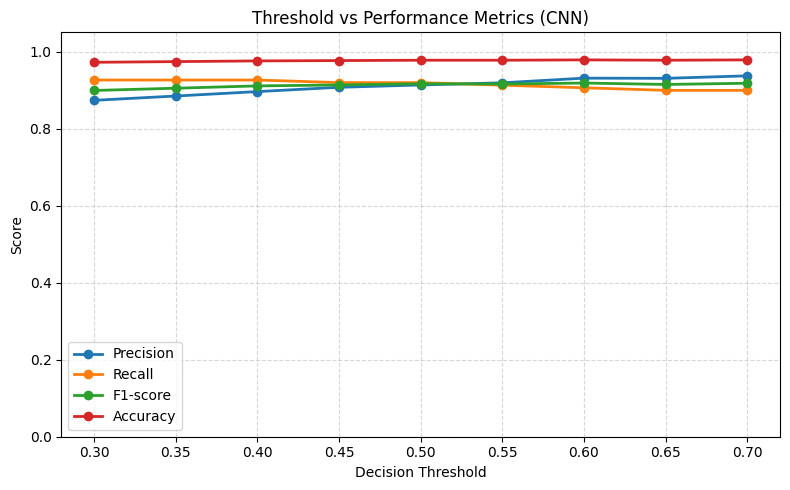

In [14]:
import matplotlib.pyplot as plt

# Sweep thresholds
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

accuracies, precisions, recalls, f1s = [], [], [], []

for t in thresholds:
    preds_t = (all_probs >= t).astype(int)
    accuracies.append(accuracy_score(all_labels, preds_t))
    precisions.append(precision_score(all_labels, preds_t, zero_division=0))
    recalls.append(recall_score(all_labels, preds_t, zero_division=0))
    f1s.append(f1_score(all_labels, preds_t, zero_division=0))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, marker='o', linewidth=2, label='Precision')
plt.plot(thresholds, recalls,    marker='o', linewidth=2, label='Recall')
plt.plot(thresholds, f1s,        marker='o', linewidth=2, label='F1-score')
plt.plot(thresholds, accuracies, marker='o', linewidth=2, label='Accuracy')

plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Threshold vs Performance Metrics (CNN)')
plt.ylim([0, 1.05])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

=> Recall rate pretty poor, at Decision threshol 0.3 seems highest but precision is lowest